In [1]:
# ===== 라이브러리 =====
import os, glob                       # 파일/폴더 다루기
import duckdb                         # SQL로 큰 데이터 다루는 도구
import pandas as pd                   # 표 데이터
import numpy as np                    # 숫자 계산
import matplotlib.pyplot as plt       # 그래프

plt.rcParams['font.family'] = 'Malgun Gothic'     # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)

# ===== 경로 (01 노트북과 동일) =====
RAW  = '../data/raw/epoch_data'          # csv 17개
PROC = '../data/processed'               # parquet 등 직접 만든 파일

# ===== 기준일 =====
D          = '2026-09-01'     # 본선 테스트 (리더보드 제출용)
TRAIN_DATE = '2026-08-11'     # 학습 + EDA에 쓸 기준일
HOLD_DATE  = '2026-08-25'     # 홀드아웃 — 4주차 전까지 열어보지 않음

# ===== view_5d 사용 기준 =====
# 코드북 2.4절 규칙대로, 기준일로부터 5일(120시간)이 지난 영상의 view_5d만 사용
CUT_HOURS = 121    # 120h + 여유 1h

# ===== DuckDB 연결 + 테이블 등록 =====
con = duckdb.connect()
con.sql("SET memory_limit = '4GB'")

for p in sorted(glob.glob(f'{RAW}/*.csv')):
    name = os.path.splitext(os.path.basename(p))[0]      # 'videos.csv' → 'videos'
    con.sql(f"""CREATE OR REPLACE VIEW {name} AS
                SELECT * FROM read_csv('{p}', header=true, auto_detect=true)""")

# 스냅샷은 01 노트북에서 만든 parquet 재사용
con.sql(f"CREATE OR REPLACE VIEW video_snapshots AS SELECT * FROM '{PROC}/video_snapshots.parquet'")

print('준비 완료')

준비 완료


In [2]:
# 테스트 분리

# train_labels: row_id = "채널ID_기준일", target = 0(안뜸)/1(뜸)
tl = pd.read_csv(f'{RAW}/train_labels.csv')
tl['channel_id'] = tl['row_id'].str.rsplit('_', n=1).str[0]   # row_id 앞부분 = 채널 ID
tl['ref_date']   = tl['row_id'].str.rsplit('_', n=1).str[1]   # row_id 뒷부분 = 기준일

# ===== 시간 기준으로 분리 =====
# 랜덤 분리를 안 쓰는 이유: 같은 채널이 두 기준일에 다 나올 수 있어서,
# 랜덤으로 섞으면 비슷한 정보가 양쪽에 들어가 검증 점수가 부풀려짐
train   = tl[tl.ref_date == TRAIN_DATE].reset_index(drop=True)   # 학습 + EDA용
holdout = tl[tl.ref_date == HOLD_DATE].reset_index(drop=True)    # 4주차 전까지 안 열어봄

print(f'train  ({TRAIN_DATE}): {len(train)}행, 양성 비율 {train.target.mean():.3f}')
print(f'holdout({HOLD_DATE}): {len(holdout)}행, 양성 비율 {holdout.target.mean():.3f}')
print('두 기준일에 겹치는 채널 수:', len(set(train.channel_id) & set(holdout.channel_id)))

# 나중에 다른 노트북에서도 똑같이 불러 쓸 수 있게 저장
train.to_csv(f'{PROC}/split_train.csv', index=False)
holdout.to_csv(f'{PROC}/split_holdout.csv', index=False)

# ⚠️ 이 지점 이후로 holdout 변수는 4주차 "테스트 1회 평가" 전까지 절대 사용 금지

train  (2026-08-11): 601행, 양성 비율 0.201
holdout(2026-08-25): 666행, 양성 비율 0.201
두 기준일에 겹치는 채널 수: 600


train(601행)만 가지고 EDA와 피처 설계 진행

In [3]:
def eda_table(Dref):
    """기준일 Dref 시점에 알 수 있는 정보로 채널별 요약값을 계산"""

    return con.sql(f"""
    WITH v5 AS (            -- 롱폼 view_5d 기반 성적 (기준일 시점 기준으로만 사용)
        SELECT channel_id,
               COUNT(*)                                       AS n_long_5d,     -- view_5d 있는 롱폼 수
               MEDIAN(view_5d)                                AS past_med,      -- 과거 전체 중앙값 (라벨의 past_score)
               MEDIAN(view_5d) FILTER (
                   WHERE published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                              AS recent14_med,  -- 최근 14일 중앙값
               MEDIAN(like_5d / NULLIF(view_5d, 0))           AS like_rate      -- 좋아요/조회수 비율 중앙값
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR     -- 기준일 시점에 5일 지난 영상만
        GROUP BY 1
    ),
    up AS (                 -- 업로드 기록 (업로드 "시각"만 쓰므로 기준일 직전까지 전부 알 수 있음)
        SELECT channel_id,
               COUNT(*) FILTER (
                   WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_long_14,    -- 최근 14일 롱폼 수
               COUNT(*) FILTER (
                   WHERE is_shorts = 1 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_short_14,    -- 최근 14일 쇼츠 수
               DATE_DIFF('hour', MAX(published_at) FILTER (WHERE is_shorts = 0), TIMESTAMP '{Dref}') / 24.0
                                                                                 AS days_since_long -- 마지막 롱폼 후 경과일
        FROM videos
        WHERE published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    ),
    ch AS (                 -- 채널 기본 정보
        SELECT channel_id,
               DATE_DIFF('day', created_at, TIMESTAMP '{Dref}') AS channel_age_days,   -- 채널 개설 후 경과일
               country
        FROM channels
    )
    SELECT * FROM v5 LEFT JOIN up USING (channel_id) LEFT JOIN ch USING (channel_id)
    """).df()

# train(08-11)에 요약값 붙이기
eda = train.merge(eda_table(TRAIN_DATE), on='channel_id', how='left')

# ===== 파생값 =====
eda['momentum14']  = np.log1p(eda.recent14_med) - np.log1p(eda.past_med)     # 최근이 과거보다 얼마나 잘 나오는가
eda['short_ratio'] = eda.n_short_14 / (eda.n_short_14 + eda.n_long_14).replace(0, np.nan)   # 최근 쇼츠 비중

print(eda.shape)
eda.describe().T

(601, 15)


,count,mean,std,min,25%,50%,75%,max
target,601.0,0.201331,0.401329,0.000000,0.000000,0.000000,0.000000,1.000000e+00
n_long_5d,601.0,12.469218,16.152383,1.000000,5.000000,9.000000,14.000000,1.880000e+02
past_med,601.0,40097.590682,80325.106773,55.000000,3344.500000,13363.500000,39298.000000,8.388945e+05
recent14_med,568.0,44974.591549,102003.656920,0.000000,3267.750000,14507.000000,45436.250000,1.249627e+06
like_rate,590.0,0.017829,0.013575,0.000000,0.008422,0.014531,0.022092,9.280272e-02
n_long_14,601.0,9.535774,11.290961,0.000000,4.000000,7.000000,11.000000,9.800000e+01
n_short_14,601.0,3.492512,8.796990,0.000000,0.000000,0.000000,3.000000,9.800000e+01
days_since_long,601.0,2.371950,3.233419,0.041667,0.583333,1.333333,2.833333,2.575000e+01
channel_age_days,601.0,3042.881864,1564.939717,34.000000,1774.000000,3051.000000,4388.000000,7.504000e+03
momentum14,568.0,-0.015725,0.568323,-7.314220,-0.130751,0.000000,0.119338,3.584660e+00


- 601행 중 recent14_med/momentum14는 568개(33개 결측),
  like_rate는 590개, short_ratio는 594개만 값이 있음.
  past_med는 최소 55 ~ 최대 838,894로 편차가 매우 큼.
  n_short_14 중앙값 0, 75%도 3 → 대부분 채널은 최근 쇼츠를 거의 안 올림.
  days_since_long 중앙값 1.3일 → 대부분 최근에도 꾸준히 롱폼을 올림.

- recent14_med 결측 33개는 "최근 14일에 롱폼을 안 올린 채널"로 보임
  (영상이 없으면 MEDIAN이 NULL). past_med가 매우 치우쳐 있어 그대로 쓰면 큰 채널에
  좌우될 수 있음 → log 변환이나 순위가 필요해 보임!

-> 셀 3에서 결측 패턴을 확인, 셀 4에서 각 값이 실제로
  Rising 여부와 관련 있는지 본다.

In [4]:
# 피처별 결측 비율
print(eda.isna().mean().sort_values(ascending=False).round(3).to_frame('결측 비율'))

print()
# recent14_med이 비는 채널은 정말로 "최근 14일 롱폼 업로드가 0"인지 확인
check = eda[eda.recent14_med.isna()][['channel_id', 'n_long_14', 'days_since_long']]
print('recent14_med 결측 채널 수:', len(check))
print(check.describe())   # n_long_14가 전부 0 근처면 추측이 맞는 것

                  결측 비율
country           0.106
momentum14        0.055
recent14_med      0.055
like_rate         0.018
short_ratio       0.012
target            0.000
row_id            0.000
past_med          0.000
n_long_5d         0.000
ref_date          0.000
channel_id        0.000
days_since_long   0.000
n_short_14        0.000
n_long_14         0.000
channel_age_days  0.000

recent14_med 결측 채널 수: 33
       n_long_14  days_since_long
count  33.000000        33.000000
mean    1.787879         7.886364
std     2.509452         8.010703
min     0.000000         0.125000
25%     0.000000         1.541667
50%     1.000000         3.625000
75%     2.000000        16.125000
max    10.000000        25.750000


In [5]:
# n_long_14 (업로드는 했음) vs recent14_med 결측 (측정 가능한 게 없음)을 나눠서 봄
eda['has_recent_upload']  = eda.n_long_14 > 0                    # 최근 14일에 롱폼을 올렸는지
eda['has_recent_measure'] = eda.recent14_med.notna()             # 그중 측정 가능한 view_5d가 있는지

pd.crosstab(eda.has_recent_upload, eda.has_recent_measure,
            rownames=['최근_업로드함'], colnames=['측정_가능'])

측정_가능,False,True
최근_업로드함,,
False,12,0
True,21,568


21개 채널이 "최근에 올렸지만 아직 측정 불가" 상태 -> 결측을 평균이나 0으로 채우지 않아야 한다....

In [7]:
# 셀 2 수정: 결측을 의미별로 나눠서 처리

def eda_table(Dref):
    """기준일 Dref 시점에 알 수 있는 정보로 채널별 요약값을 계산"""

    return con.sql(f"""
    WITH v5 AS (            -- 롱폼 view_5d 기반 성적 (기준일 시점 기준으로만 사용)
        SELECT channel_id,
               COUNT(*)                                       AS n_long_5d,     -- view_5d 있는 롱폼 수
               MEDIAN(view_5d)                                AS past_med,      -- 과거 전체 중앙값 (라벨의 past_score)
               MEDIAN(view_5d) FILTER (
                   WHERE published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                              AS recent14_med,  -- 최근 14일 중앙값 (측정 가능한 것만)
               MEDIAN(like_5d / NULLIF(view_5d, 0))           AS like_rate
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}' - INTERVAL {CUT_HOURS} HOUR
        GROUP BY 1
    ),
    up AS (                 -- 업로드 기록 (업로드 "시각"만 쓰므로 기준일 직전까지 전부 알 수 있음)
        SELECT channel_id,
               COUNT(*) FILTER (
                   WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_long_14,
               COUNT(*) FILTER (
                   WHERE is_shorts = 1 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY
               )                                                                AS n_short_14,
               DATE_DIFF('hour', MAX(published_at) FILTER (WHERE is_shorts = 0), TIMESTAMP '{Dref}') / 24.0
                                                                                 AS days_since_long
        FROM videos
        WHERE published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    ),
    ch AS (
        SELECT channel_id,
               DATE_DIFF('day', created_at, TIMESTAMP '{Dref}') AS channel_age_days,
               country
        FROM channels
    )
    SELECT * FROM v5 LEFT JOIN up USING (channel_id) LEFT JOIN ch USING (channel_id)
    """).df()

eda = train.merge(eda_table(TRAIN_DATE), on='channel_id', how='left')

# ===== 결측을 의미별로 3가지 상태로 나눔 =====
# A. has_recent_upload=False → 최근 14일에 롱폼을 아예 안 올림 (활동 저하 신호일 수 있음)
# B. has_recent_upload=True, has_recent_measure=False → 올렸지만 아직 측정 전 (정보 없음, 모름)
# C. has_recent_measure=True → 비교 가능 (momentum14 계산)
eda['has_recent_upload']  = eda.n_long_14 > 0
eda['has_recent_measure'] = eda.recent14_med.notna()

conditions = [
    ~eda['has_recent_upload'],                                   # A: 안 올림
    eda['has_recent_upload'] & ~eda['has_recent_measure'],       # B: 올렸지만 측정 전
    eda['has_recent_measure'],                                   # C: 측정 가능
]
eda['recent_status'] = np.select(
    conditions,
    ['안_올림', '측정_전', '측정_가능'],
    default='알수없음'      # ← 이 줄 추가 (세 조건에 다 안 걸리는 경우 대비)
)
# momentum14는 "측정 가능"일 때만 계산. 나머지는 NaN으로 남김 (0으로 채우지 않음!)
eda['momentum14']  = np.where(
    eda['recent_status'] == '측정_가능',
    np.log1p(eda.recent14_med) - np.log1p(eda.past_med),
    np.nan
)
eda['short_ratio'] = eda.n_short_14 / (eda.n_short_14 + eda.n_long_14).replace(0, np.nan)

print(eda.shape)
eda['recent_status'].value_counts()

(601, 18)


recent_status
측정_가능    568
측정_전      21
안_올림      12
Name: count, dtype: int64


- 601개 채널 중 측정_가능 568, 측정_전 21, 안_올림 12로 나뉨.

- momentum14는 "측정_가능" 568개에만 값이 있고 나머지는 결측으로
  남겨뒀다. recent_status 자체도 범주형 피처로 쓸 수 있다
  (예: "안_올림"인 채널은 future에도 안 올릴 가능성이 높아 Rising 될 확률이 낮을 것임).

-> momentum14, past_med 등 수치형 값들의 구간별 Rising
  비율을 보고, recent_status별 Rising 비율도 따로 확인.

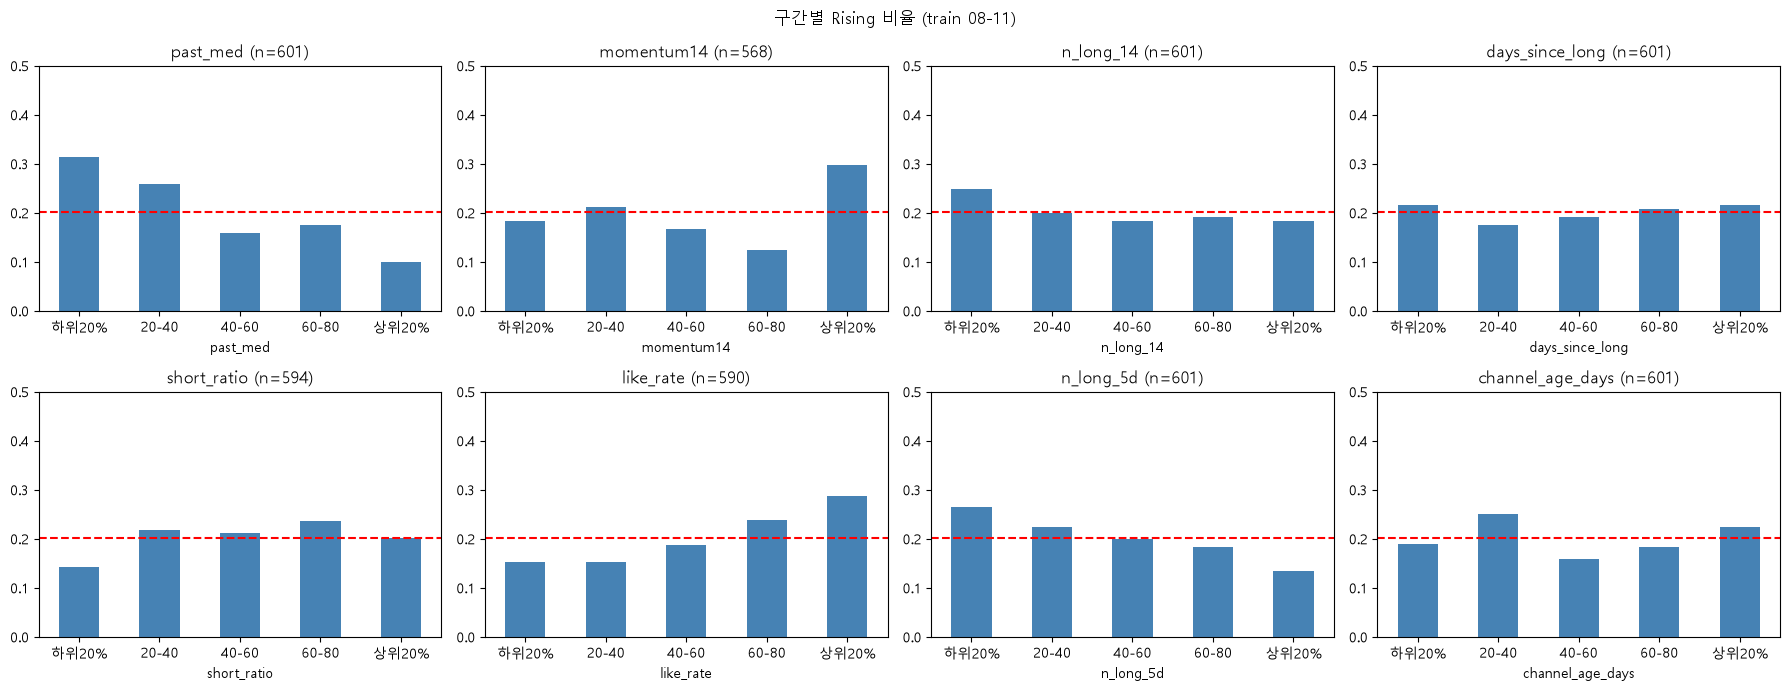

In [8]:
# 수치형 값들의 구간별 Rising 비율 

# 각 값을 5구간으로 나눠서, 구간마다 Rising(target=1) 비율이 어떻게 바뀌는지 확인
# 전체 평균은 0.201 (빨간 선) → 구간별로 이 선에서 멀어질수록 쓸모 있는 신호
COLS = ['past_med', 'momentum14', 'n_long_14', 'days_since_long',
        'short_ratio', 'like_rate', 'n_long_5d', 'channel_age_days']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), COLS):
    x = eda[[col, 'target']].dropna()                                    # 결측 제외하고 구간 나눔
    bins = pd.qcut(x[col].rank(method='first'), 5,
                    labels=['하위20%', '20-40', '40-60', '60-80', '상위20%'])
    rate = x.groupby(bins, observed=True)['target'].mean()               # 구간별 Rising 비율
    rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(0.201, ls='--', c='red')                                   # 전체 평균
    ax.set_title(f'{col} (n={len(x)})')
    ax.set_ylim(0, 0.5)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('구간별 Rising 비율 (train 08-11)')
plt.tight_layout()
plt.show()

In [ ]:
# recent_status별 Rising 비율

# 범주형 값은 구간을 나눌 필요 없이 그룹별로 바로 비교
rate = eda.groupby('recent_status')['target'].agg(['mean', 'count'])
rate.columns = ['Rising_비율', '채널_수']
rate

,Rising_비율,채널_수
recent_status,,
안_올림,0.166667,12
측정_가능,0.197183,568
측정_전,0.333333,21


1. past_med: 평균 회귀가 확실함
하위20%는 0.31, 상위20%는 0.10으로 3배 차이가 난다. 과거 성적이 낮을수록 Rising 될 확률이 높음 -> 예상했던 평균 회귀가 그래프로 확인.

2. momentum14: 양 끝이 다 높은 U자 모양
하위20%(0.18)와 상위20%(0.30)가 둘 다 평균보다 높고, 중간(60-80)이 가장 낮다(0.13). 이건 momentum14가 past_med와 많이 겹쳐서 생기는 현상일 가능성이 있다.(past_med가 작은 채널은 log1p 계산상 momentum14가 쉽게 큰 음수나 큰 양수로 튀기 때문..)  -> 둘의 상관관계 추가 확인 필요

3. recent_status="측정_전"  
21개뿐이지만 Rising 비율이 0.333으로 전체 평균의 1.65배이다. "최근에 롱폼을 올렸는데 아직 집계가 안 된" 채널이 뜰 확률이 꽤 높다는 뜻.. 

4. like_rate: 계단식으로 증가
하위20%(0.15)부터 상위20%(0.29)까지 꾸준히 올라감. 좋아요 비율이 높을수록 Rising 가능성이 높다.


[큰 의미 X]

n_long_14, days_since_long, channel_age_days: 막대들이 평균(0.2) 주변에 몰려 있어 신호가 약함.

n_long_5d: 하위20%(0.26)에서 상위20%(0.14)로 줄어드는 경향은 있지만, past_med만큼 뚜렷하지는 X.

short_ratio: 하위20%만 낮고(0.14) 나머지는 평평함.

상관계수: 0.03


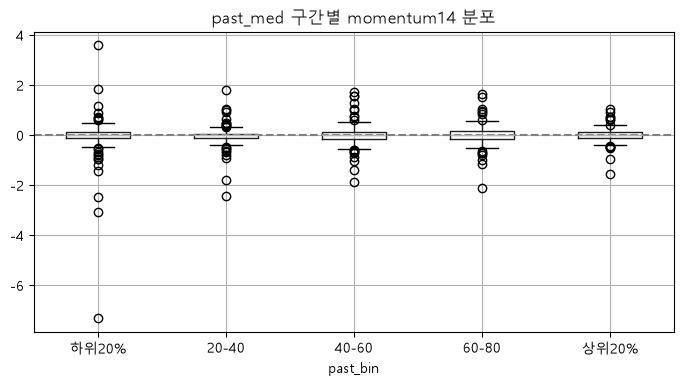

In [11]:
# momentum14와 past_med 관계 확인

# momentum14 = log1p(recent) - log1p(past) 이므로 past_med와 구조적으로 얽혀 있을 수 있음
print('상관계수:', eda[['past_med', 'momentum14']].corr().iloc[0, 1].round(3))

# past_med 구간별로 momentum14의 분포가 어떻게 다른지
x = eda.dropna(subset=['momentum14']).copy()
x['past_bin'] = pd.qcut(x.past_med.rank(method='first'), 5,
                         labels=['하위20%', '20-40', '40-60', '60-80', '상위20%'])
fig, ax = plt.subplots(figsize=(8, 4))
x.boxplot(column='momentum14', by='past_bin', ax=ax)
plt.suptitle('')
plt.title('past_med 구간별 momentum14 분포')
plt.axhline(0, ls='--', c='gray')
plt.show()

In [12]:
# 두 신호를 교차로 봤을 때 (2x2)

# past_med가 낮은 것과 momentum14가 높은 것 중 뭐가 더 중요한지, 혹은 같이 작용하는지
x = eda.dropna(subset=['momentum14']).copy()
x['past_low']  = x.past_med   < x.past_med.median()       # 과거 성적이 낮은 절반
x['mom_high']  = x.momentum14 > x.momentum14.median()     # 최근 성장세가 높은 절반

pd.pivot_table(x, index='past_low', columns='mom_high', values='target',
                aggfunc=['mean', 'count'])

mean           count      
mom_high     False     True  False True 
past_low                                
False     0.113924  0.126984   158   126
True      0.277778  0.270492   162   122

momentum14는 거의 영향이 없음

past_low(과거 성적)로 나누면 0.114 vs 0.278로 2.4배 차이가 나는데, mom_high(최근 모멘텀)로 나누면 거의 차이가 없다 (0.127 vs 0.114, 0.270 vs 0.278). 즉 지금 만든 momentum14는 중간값 기준 이분(위/아래)으로는 예측력이 거의 없고, past_med가 중요.

아까 구간별 그래프에서 momentum14가 U자로 보였던 건 양 끝 20%에 극단값(박스플롯에 보이는 이상치들, 최대 3.6, 최소 -7.3)이 몰려 있어서였을 가능성이 크다. 중간값 분할에서는 그 효과가 사라지는 걸 보면, momentum14는 노이즈가 많은 피처로 보이는데 원인은 n이 작은 채널(최근 영상 1~2개)에서 중앙값이 불안정하게 튀기 때문일 수 있다.

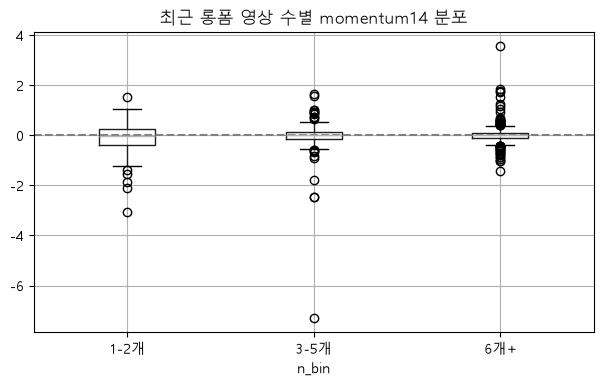

,std,count
n_bin,,
1-2개,0.761348,67
3-5개,0.795272,141
6개+,0.390676,360


In [13]:
# momentum14가 표본 수 때문에 불안정한지 확인 

# 최근 영상 수가 적을수록 momentum14가 더 극단적으로 튀는지 확인
x = eda.dropna(subset=['momentum14', 'n_long_14']).copy()
x['n_bin'] = pd.cut(x.n_long_14, [0, 2, 5, 100], labels=['1-2개', '3-5개', '6개+'])
x.boxplot(column='momentum14', by='n_bin', figsize=(7, 4))
plt.suptitle('')
plt.title('최근 롱폼 영상 수별 momentum14 분포')
plt.axhline(0, ls='--', c='gray')
plt.show()

x.groupby('n_bin', observed=True)['momentum14'].agg(['std', 'count'])

momentum14는 영상 수가 적을 때 중앙값이 불안정해져서
  신뢰하기 어렵다. 표본이 충분한 채널(6개+)에서만 값이 0 근처로 안정적이다.

momentum14를 버리기보다는, **영상 수로 신뢰도를 반영하는 형태**로 다듬는 게 낫다.

| 안 | 방법 | 장단점 |
|---|---|---|
| A | 영상 수 적으면 momentum14를 결측(NaN) 처리 | 간단하지만 정보를 버림 |
| B | `n_long_14`를 별도 피처로 같이 넣기 (모델이 알아서 가중치 학습) | 트리 모델(LightGBM)에 적합, 추천 |
| C | 영상 수로 축소(shrinkage): 적을수록 0에 가깝게 당기기 | 통계적으로 정석이지만 구현이 더 필요 |

-> B안 채택. 2주차에서 momentum14는 버리지 않고 n_long_14와
  함께 모델에 넣는다(트리 모델이 상호작용을 학습하도록). 파생변수 우선순위는
  past_med > recent_status > like_rate > momentum14(+n_long_14) > 나머지